In [1]:
# !pip install pandas-gbq
# !pip install google-cloud-bigquery

In [2]:
# from google.colab import auth
# auth.authenticate_user()

# Load Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

hotel_booking = '/content/drive/MyDrive/lab/out_hotel_booking_1000_with_checkout.csv'
hotel_product = '/content/drive/MyDrive/lab/out_additional_products_1000.csv'

In [5]:
hotel_booking_df = pd.read_csv(hotel_booking)
hotel_product_df = pd.read_csv(hotel_product)

In [6]:
# Upload data to BigQuery
# project_id = 'cedar-helper-348603'

# table_id = 'Hotels.out_hotel_booking_1000_with_checkout'

# from pandas_gbq import to_gbq

# to_gbq(
#     dataframe=hotel_booking_df,
#     destination_table=table_id,
#     project_id=project_id,
#     if_exists='replace'
# )

In [7]:
hotel_booking_df.head()

,Booking_ID,Tanggal_Booking,Tanggal_CheckIn,Tanggal_CheckOut,Lama_Menginap,Room_ID,Tipe_Kamar,Harga_per_Malam,Status_Reservasi,Kanal_Distribusi
0,B0001,2025-03-07,2025-05-28,2025-05-30,2,SU028,Suite,1000000,Check-in,Direct Booking
1,B0002,2025-05-05,2025-05-23,2025-05-26,3,ST074,Standard,300000,Check-in,OTA (Booking.com)
2,B0003,2025-08-19,2025-11-03,2025-11-05,2,SU013,Suite,1000000,Check-in,Direct Booking
3,B0004,2025-02-08,2025-04-14,2025-04-15,1,ST018,Standard,300000,Check-in,OTA (Booking.com)
4,B0005,2025-08-23,2025-11-01,2025-11-02,1,SU014,Suite,1000000,Check-in,Direct Booking


In [8]:
print(hotel_booking_df.Tipe_Kamar.unique())
print(hotel_booking_df.Status_Reservasi.unique())
print(hotel_booking_df.Kanal_Distribusi.unique())

['Suite' 'Standard' 'Deluxe']
['Check-in' 'Cancel']
['Direct Booking' 'OTA (Booking.com)' 'Corporate' 'OTA (Agoda)']


In [9]:
hotel_product_df.head()

,Product_ID,Booking_ID,Product_Name,Quantity,Price_per_Unit,Total_Price
0,PROD-0001,B0822,Late Checkout,1,100000,100000
1,PROD-0002,B0308,Late Checkout,1,100000,100000
2,PROD-0003,B0669,Massage Service,1,350000,350000
3,PROD-0004,B0214,Laundry Service,3,75000,225000
4,PROD-0005,B0282,Mini Bar Refill,1,120000,120000


In [10]:
print(hotel_product_df.Product_Name.unique())

['Late Checkout' 'Massage Service' 'Laundry Service' 'Mini Bar Refill'
 'Room Service' 'Dinner Buffet' 'Spa Package' 'Airport Transfer'
 'Tour Package' 'Breakfast Buffet']


# KPI Metrics: ADR → Occupancy → RevPAR → TRevPAR

## Calculate total revenue (room vs. ancillary)

Calculate the total revenue generated from room bookings and the total revenue from additional product sales (ancillary revenue).


In [11]:
checked_in_bookings_df = hotel_booking_df[hotel_booking_df['Status_Reservasi'] == 'Check-in'].copy()
total_room_revenue = (checked_in_bookings_df['Harga_per_Malam'] * checked_in_bookings_df['Lama_Menginap']).sum()

# 1. Gabungkan (Left Join) data produk dengan data booking (ambil status dan tipe kamar saja)
master_ancillary_df = hotel_product_df.merge(
    hotel_booking_df[['Booking_ID', 'Status_Reservasi', 'Tipe_Kamar']],
    on='Booking_ID',
    how='left'
)

# 2. Pisahkan DataFrame khusus untuk transaksi yang terealisasi (Check-in)
realized_ancillary_df = master_ancillary_df[master_ancillary_df['Status_Reservasi'] == 'Check-in']

# 3. Hitung total pendapatan tambahan yang akurat
total_ancillary_revenue = realized_ancillary_df['Total_Price'].sum()


print(f"Total Room Revenue: {total_room_revenue:,.0f}")
print(f"Total Realized Ancillary Revenue: IDR {total_ancillary_revenue:,.0f}")

Total Room Revenue: 1,635,400,000
Total Realized Ancillary Revenue: IDR 257,430,000


In [12]:
# Configuration
total_kamar = 92
# Using the 2025 date range as established in previous cells
start_date = pd.to_datetime('2025-01-01')
end_date = pd.to_datetime('2025-12-31')
total_hari = (end_date - start_date).days + 1
total_room_nights_available = total_kamar * total_hari

# 1. ADR (Average Daily Rate)
# Filter only checked-in bookings to get actual realized revenue
checked_in_only = hotel_booking_df[hotel_booking_df['Status_Reservasi'] == 'Check-in']
total_room_revenue = (checked_in_only['Harga_per_Malam'] * checked_in_only['Lama_Menginap']).sum()
total_occupied_nights = checked_in_only['Lama_Menginap'].sum()
adr = total_room_revenue / total_occupied_nights

# 2. Occupancy Rate
occupancy_rate = (total_occupied_nights / total_room_nights_available) * 100

# 3. RevPAR (Revenue Per Available Room)
revpar = total_room_revenue / total_room_nights_available

# 4. TRevPAR (Total Revenue Per Available Room)
# Include ancillary revenue from products
total_revenue = total_room_revenue + total_ancillary_revenue
trevpar = total_revenue / total_room_nights_available

# Display Results
print(f"--- Revenue Health Check (Total Rooms: {total_kamar}) ---")
print(f"Total Room Nights Available: {total_room_nights_available}")
print(f"Total Room Nights Occupied:  {total_occupied_nights}")
print(f"Occupancy Rate:              {occupancy_rate:.2f}%")
print(f"ADR (Average Daily Rate):    IDR {adr:,.2f}")
print(f"RevPAR:                      IDR {revpar:,.2f}")
print(f"TRevPAR (Total RevPAR):      IDR {trevpar:,.2f}")

--- Revenue Health Check (Total Rooms: 92) ---
Total Room Nights Available: 33580
Total Room Nights Occupied:  2791
Occupancy Rate:              8.31%
ADR (Average Daily Rate):    IDR 585,954.85
RevPAR:                      IDR 48,701.61
TRevPAR (Total RevPAR):      IDR 56,367.78


## Performance Decomposition: What drives RevPAR?

To understand RevPAR performance, we decompose it into its core components: ADR (Pricing Power) and Occupancy (Volume). We will specifically look at:
1. **ADR Breakdown**: Comparison by Distribution Channel and Room Type.
2. **LOS (Length of Stay)**: How long guests stay and its impact on room availability.
3. **Lead Time**: Booking windows and their relationship with ADR.

## Identify top room type by revenue

Determine which room type contributes the highest revenue from bookings.


Calculate the total revenue for each booking by multiplying 'Harga_per_Malam' and 'Lama_Menginap', then group the DataFrame by 'Tipe_Kamar' and sum these revenues to find the total revenue per room type.



In [13]:
checked_in_bookings_df.loc[:, 'Total_Booking_Revenue'] = checked_in_bookings_df['Harga_per_Malam'] * checked_in_bookings_df['Lama_Menginap']
room_type_revenue = checked_in_bookings_df.groupby('Tipe_Kamar')['Total_Booking_Revenue'].sum().sort_values(ascending=False)
top_room_type = room_type_revenue.index[0]
top_room_revenue = room_type_revenue.iloc[0]

print(f"The room type with the highest revenue is '{top_room_type}' with a total revenue of {top_room_revenue:,.0f}.")

The room type with the highest revenue is 'Suite' with a total revenue of 869,000,000.


In [14]:
room_type_revenue

,Total_Booking_Revenue
Tipe_Kamar,
Suite,869000000
Deluxe,474500000
Standard,291900000


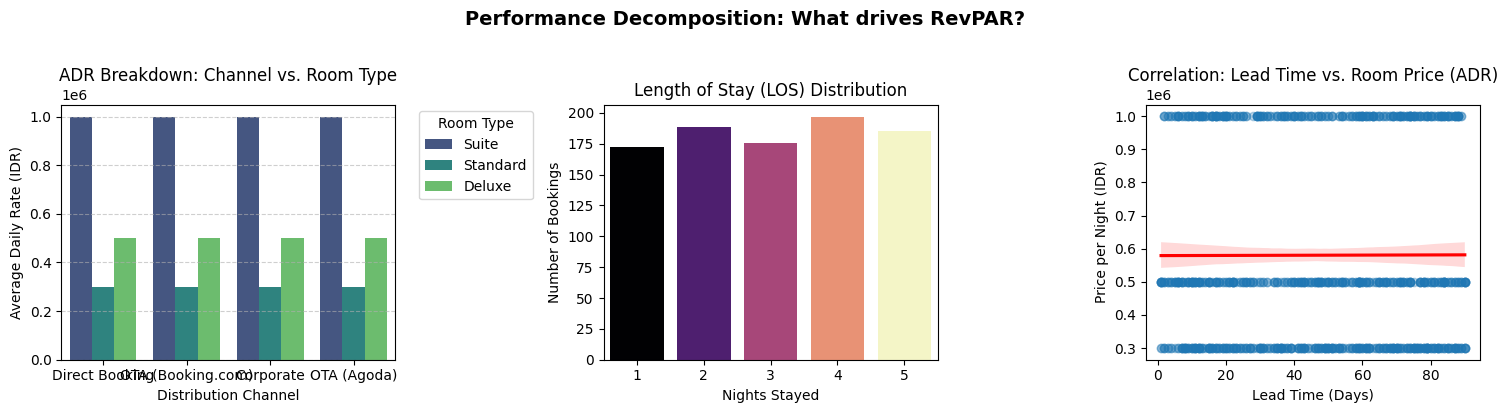

In [15]:
# Ensure dates are datetime objects and calculate Lead_Time in the main dataframe
hotel_booking_df['Tanggal_Booking'] = pd.to_datetime(hotel_booking_df['Tanggal_Booking'])
hotel_booking_df['Tanggal_CheckIn'] = pd.to_datetime(hotel_booking_df['Tanggal_CheckIn'])
hotel_booking_df['Lead_Time'] = (hotel_booking_df['Tanggal_CheckIn'] - hotel_booking_df['Tanggal_Booking']).dt.days

# Re-filter for realized stays to ensure new columns (like Lead_Time) are present
checked_in_only = hotel_booking_df[hotel_booking_df['Status_Reservasi'] == 'Check-in']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Performance Decomposition: What drives RevPAR?', fontsize=14, fontweight='bold', y=1.02)

# 1. ADR Analysis by Channel & Room Type
sns.barplot(x='Kanal_Distribusi', y='Harga_per_Malam', hue='Tipe_Kamar', data=checked_in_only, palette='viridis', ax=axes[0])
axes[0].set_title('ADR Breakdown: Channel vs. Room Type')
axes[0].set_ylabel('Average Daily Rate (IDR)')
axes[0].set_xlabel('Distribution Channel')
axes[0].legend(title='Room Type', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# 2. LOS (Length of Stay) Distribution
sns.countplot(x='Lama_Menginap', data=checked_in_only, palette='magma', hue='Lama_Menginap', legend=False, ax=axes[1])
axes[1].set_title('Length of Stay (LOS) Distribution')
axes[1].set_xlabel('Nights Stayed')
axes[1].set_ylabel('Number of Bookings')

# 3. Lead Time vs. ADR Correlation
sns.regplot(x='Lead_Time', y='Harga_per_Malam', data=checked_in_only, scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=axes[2])
axes[2].set_title('Correlation: Lead Time vs. Room Price (ADR)')
axes[2].set_xlabel('Lead Time (Days)')
axes[2].set_ylabel('Price per Night (IDR)')

plt.tight_layout()
plt.savefig('play00_distribusi_data.png', bbox_inches='tight')
plt.show()

In [16]:
# Calculate Summary Metrics for Decomposition
channel_adr = checked_in_only.groupby('Kanal_Distribusi')['Harga_per_Malam'].mean().sort_values(ascending=False)
room_adr = checked_in_only.groupby('Tipe_Kamar')['Harga_per_Malam'].mean().sort_values(ascending=False)
avg_los = checked_in_only['Lama_Menginap'].mean()

print("--- ADR by Channel ---")
print(channel_adr.apply(lambda x: f"IDR {x:,.2f}"))
print("\n--- ADR by Room Type ---")
print(room_adr.apply(lambda x: f"IDR {x:,.2f}"))
print(f"\nAverage LOS: {avg_los:.2f} nights")

--- ADR by Channel ---
Kanal_Distribusi
OTA (Booking.com)    IDR 607,049.61
Direct Booking       IDR 567,450.98
OTA (Agoda)          IDR 560,101.01
Corporate            IDR 544,578.31
Name: Harga_per_Malam, dtype: object

--- ADR by Room Type ---
Tipe_Kamar
Suite       IDR 1,000,000.00
Deluxe        IDR 500,000.00
Standard      IDR 300,000.00
Name: Harga_per_Malam, dtype: object

Average LOS: 3.04 nights


# Revenue Quality

In [17]:
# 1. Setup Commissions
komisi_map = {
    'OTA (Booking.com)': 0.18,
    'OTA (Agoda)': 0.17,
    'Direct Booking': 0.00,
    'Corporate': 0.10,
}

# 2. Net Revenue Calculation (Fixed SettingWithCopyWarning by adding .copy())
checked_in_only = hotel_booking_df[hotel_booking_df['Status_Reservasi'] == 'Check-in'].copy()

checked_in_only['Commission_Fee'] = checked_in_only.apply(lambda row: (row['Harga_per_Malam'] * row['Lama_Menginap']) * komisi_map.get(row['Kanal_Distribusi'], 0), axis=1)
checked_in_only['Net_Room_Revenue'] = (checked_in_only['Harga_per_Malam'] * checked_in_only['Lama_Menginap']) - checked_in_only['Commission_Fee']

total_gross_room_rev = (checked_in_only['Harga_per_Malam'] * checked_in_only['Lama_Menginap']).sum()
total_commission_cost = checked_in_only['Commission_Fee'].sum()
total_net_room_rev = checked_in_only['Net_Room_Revenue'].sum()

# 3. Cancellation Cost (Realized Leakage)
cancelled_only = hotel_booking_df[hotel_booking_df['Status_Reservasi'] == 'Cancel'].copy()
cancel_room_leak = (cancelled_only['Harga_per_Malam'] * cancelled_only['Lama_Menginap']).sum()

# Link products to status for ancillary leak
merged_status = pd.merge(hotel_product_df, hotel_booking_df[['Booking_ID', 'Status_Reservasi']], on='Booking_ID', how='left')
cancel_ancillary_leak = merged_status[merged_status['Status_Reservasi'] == 'Cancel']['Total_Price'].sum()
total_cancellation_leakage = cancel_room_leak + cancel_ancillary_leak

# 4. Revenue at Risk (Historical Probability)
channel_stats = hotel_booking_df.groupby('Kanal_Distribusi')['Status_Reservasi'].value_counts(normalize=True).unstack().fillna(0)
cancel_prob = channel_stats['Cancel']

hotel_booking_df['Potential_Rev'] = hotel_booking_df['Harga_per_Malam'] * hotel_booking_df['Lama_Menginap']
hotel_booking_df['Prob_Cancel'] = hotel_booking_df['Kanal_Distribusi'].map(cancel_prob)
revenue_at_risk = (hotel_booking_df[hotel_booking_df['Status_Reservasi'] == 'Check-in']['Potential_Rev'] * hotel_booking_df['Prob_Cancel']).sum()

# 5. Revenue Leakage by Product
leakage_by_product = merged_status[merged_status['Status_Reservasi'] == 'Cancel'].groupby('Product_Name')['Total_Price'].sum().sort_values(ascending=False)

# Display Results
print("--- Revenue Quality Analysis ---")
print(f"Total Gross Room Revenue:      IDR {total_gross_room_rev:,.0f}")
print(f"Total Commission Paid:         IDR {total_commission_cost:,.0f}")
print(f"NET Room Revenue (P&L):        IDR {total_net_room_rev:,.0f}")
print(f"Effective Take-Home Rate:      { (total_net_room_rev/total_gross_room_rev)*100:.2f}%")
print("\n--- Leakage & Risk ---")
print(f"Cancellation Cost (Realized):  IDR {total_cancellation_leakage:,.0f} (Room + Ancillary)")
print(f"Revenue at Risk (Current):     IDR {revenue_at_risk:,.0f} (Based on historical channel volatility)")
print("\n--- Top 3 Product Leakage ---")
print(leakage_by_product.head(3).apply(lambda x: f"IDR {x:,.0f}"))

--- Revenue Quality Analysis ---
Total Gross Room Revenue:      IDR 1,635,400,000
Total Commission Paid:         IDR 197,682,000
NET Room Revenue (P&L):        IDR 1,437,718,000
Effective Take-Home Rate:      87.91%

--- Leakage & Risk ---
Cancellation Cost (Realized):  IDR 178,260,000 (Room + Ancillary)
Revenue at Risk (Current):     IDR 132,061,630 (Based on historical channel volatility)

--- Top 3 Product Leakage ---
Product_Name
Tour Package        IDR 6,500,000
Massage Service     IDR 3,500,000
Airport Transfer    IDR 3,400,000
Name: Total_Price, dtype: object


## Analyze cancellation rates by distribution channel

### Subtask:
Determine which distribution channel has the highest reservation cancellation rate.


**Reasoning**:
To begin analyzing cancellation rates, I will first filter the `hotel_booking_df` to create a new DataFrame that contains only bookings with a 'Cancel' status in the 'Status_Reservasi' column, as per the instructions.



In [18]:
cancelled_bookings_df = hotel_booking_df[hotel_booking_df['Status_Reservasi'] == 'Cancel']
print("Filtered cancelled bookings DataFrame using 'Cancel'. First 5 rows:")

Filtered cancelled bookings DataFrame using 'Cancel'. First 5 rows:


In [19]:
cancelled_bookings_df.head()

,Booking_ID,Tanggal_Booking,Tanggal_CheckIn,Tanggal_CheckOut,Lama_Menginap,Room_ID,Tipe_Kamar,Harga_per_Malam,Status_Reservasi,Kanal_Distribusi,Lead_Time,Potential_Rev,Prob_Cancel
25,B0026,2025-10-29,2025-11-19,2025-11-21,2,SU024,Suite,1000000,Cancel,OTA (Agoda),21,2000000,0.091743
28,B0029,2025-05-05,2025-06-22,2025-06-23,1,ST030,Standard,300000,Cancel,Corporate,48,300000,0.087912
47,B0048,2025-01-28,2025-04-08,2025-04-12,4,SU011,Suite,1000000,Cancel,OTA (Agoda),70,4000000,0.091743
55,B0056,2025-09-23,2025-10-24,2025-10-26,2,SU018,Suite,1000000,Cancel,OTA (Booking.com),31,2000000,0.081535
57,B0058,2025-10-12,2025-12-24,2025-12-25,1,DE110,Deluxe,500000,Cancel,Direct Booking,73,500000,0.069343


Grouping the original `hotel_booking_df` by 'Kanal_Distribusi' and count the total number of bookings for each channel to prepare for cancellation rate calculation.



In [20]:
total_bookings_per_channel = hotel_booking_df.groupby('Kanal_Distribusi').size().reset_index(name='Total_Bookings')
print("Total bookings per distribution channel:")
print(total_bookings_per_channel)

Total bookings per distribution channel:
    Kanal_Distribusi  Total_Bookings
0          Corporate              91
1     Direct Booking             274
2        OTA (Agoda)             218
3  OTA (Booking.com)             417


In [21]:
cancelled_count_per_channel = cancelled_bookings_df.groupby('Kanal_Distribusi').size().reset_index(name='Cancelled_Bookings')
cancellation_data = pd.merge(total_bookings_per_channel, cancelled_count_per_channel, on='Kanal_Distribusi', how='left')
cancellation_data['Cancelled_Bookings'] = cancellation_data['Cancelled_Bookings'].fillna(0).astype(int)
cancellation_data['Cancellation_Rate'] = cancellation_data['Cancelled_Bookings'] / cancellation_data['Total_Bookings']
cancellation_data.loc[cancellation_data['Total_Bookings'] == 0, 'Cancellation_Rate'] = 0
print("Cancellation rates per distribution channel:")
print(cancellation_data)

Cancellation rates per distribution channel:
    Kanal_Distribusi  Total_Bookings  Cancelled_Bookings  Cancellation_Rate
0          Corporate              91                   8           0.087912
1     Direct Booking             274                  19           0.069343
2        OTA (Agoda)             218                  20           0.091743
3  OTA (Booking.com)             417                  34           0.081535


In [22]:
highest_cancellation_channel = cancellation_data.loc[cancellation_data['Cancellation_Rate'].idxmax()]
print("Distribution channel with the highest cancellation rate:")
print(highest_cancellation_channel)

Distribution channel with the highest cancellation rate:
Kanal_Distribusi      OTA (Agoda)
Total_Bookings                218
Cancelled_Bookings             20
Cancellation_Rate        0.091743
Name: 2, dtype: object


# Demand Pattern

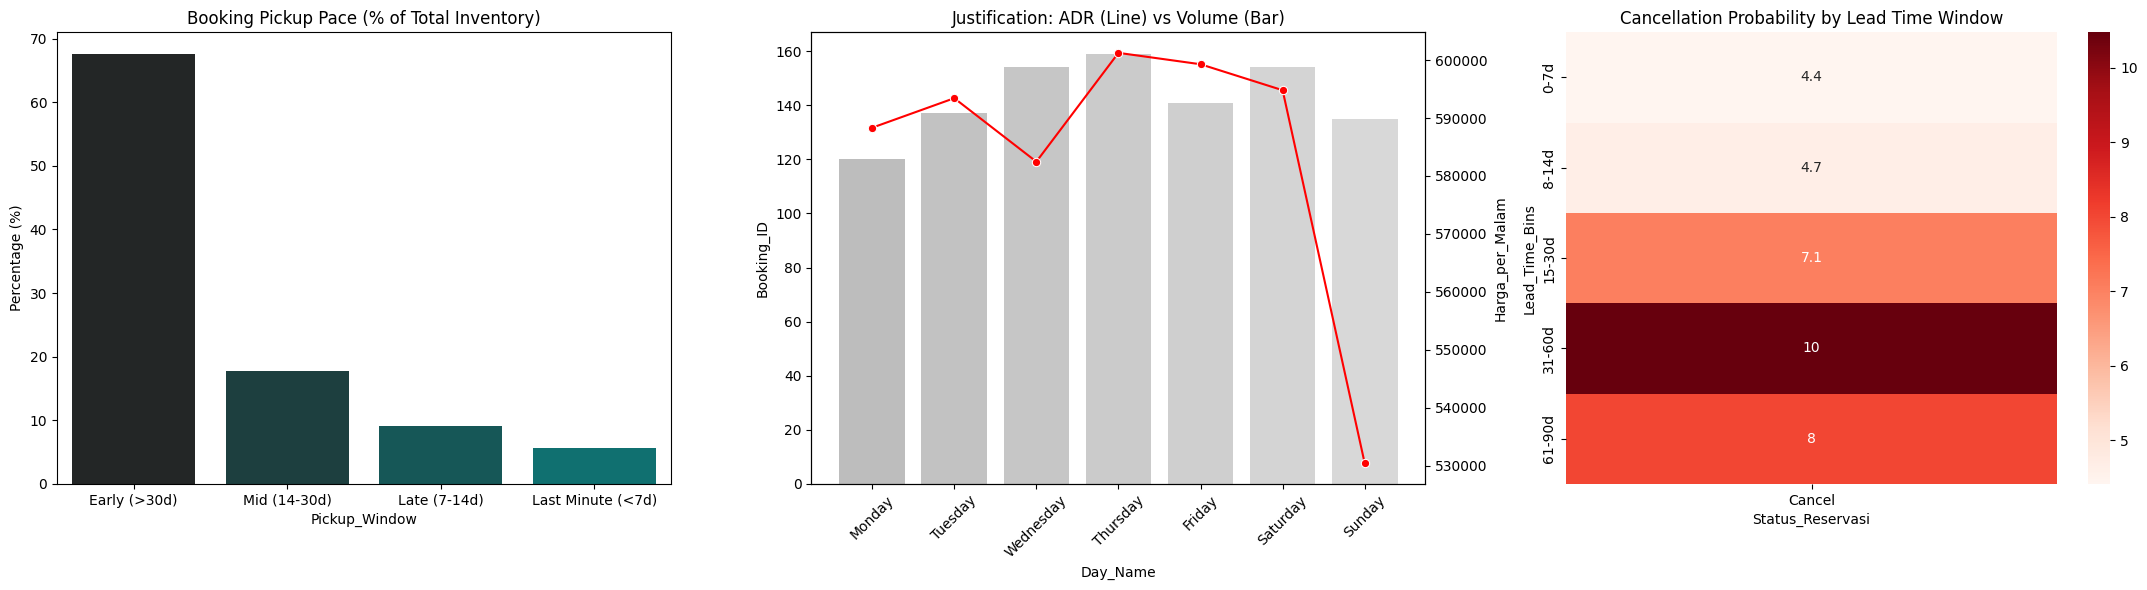

--- Demand Pattern Insights ---
Pickup Pace Early (>30d): 67.60%
Highest Risk Window: 31-60d with 10.48% cancel rate.


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Booking Pace / Pickup Analysis
def categorize_pace(days):
    if days > 30: return 'Early (>30d)'
    if days >= 14: return 'Mid (14-30d)'
    if days >= 7: return 'Late (7-14d)'
    return 'Last Minute (<7d)'

hotel_booking_df['Pickup_Window'] = hotel_booking_df['Lead_Time'].apply(categorize_pace)
pace_analysis = hotel_booking_df.groupby('Pickup_Window', observed=False).size() / len(hotel_booking_df) * 100

# 2. Weekday vs Weekend Justification
hotel_booking_df['Tanggal_CheckIn'] = pd.to_datetime(hotel_booking_df['Tanggal_CheckIn'])
hotel_booking_df['Day_Name'] = hotel_booking_df['Tanggal_CheckIn'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_stats = hotel_booking_df.groupby('Day_Name', observed=False).agg({'Harga_per_Malam': 'mean', 'Booking_ID': 'count'}).reindex(day_order)

# 3. Lead Time & Cancellation Correlation Heatmap
bins = [0, 7, 14, 30, 60, 90, 180]
labels = ['0-7d', '8-14d', '15-30d', '31-60d', '61-90d', '90d+']
hotel_booking_df['Lead_Time_Bins'] = pd.cut(hotel_booking_df['Lead_Time'], bins=bins, labels=labels)
risk_matrix = pd.crosstab(hotel_booking_df['Lead_Time_Bins'], hotel_booking_df['Status_Reservasi'], normalize='index') * 100

# --- Visualizations ---
fig, ax = plt.subplots(1, 3, figsize=(22, 6))

# Plot 1: Pickup Pace - Refactored to use palette='dark:teal'
pace_order = ['Early (>30d)', 'Mid (14-30d)', 'Late (7-14d)', 'Last Minute (<7d)']
sns.barplot(x=pace_analysis.reindex(pace_order).index, y=pace_analysis.reindex(pace_order).values, ax=ax[0], palette='dark:teal', hue=pace_analysis.reindex(pace_order).index, legend=False)
ax[0].set_title('Booking Pickup Pace (% of Total Inventory)')
ax[0].set_ylabel('Percentage (%)')

# Plot 2: Day of Week Justification
ax2_twin = ax[1].twinx()
sns.barplot(x=day_stats.index, y=day_stats['Booking_ID'], ax=ax[1], alpha=0.3, hue=day_stats.index, palette='dark:grey', legend=False)
sns.lineplot(x=day_stats.index, y=day_stats['Harga_per_Malam'], ax=ax2_twin, marker='o', color='red')
ax[1].set_title('Justification: ADR (Line) vs Volume (Bar)')
ax[1].set_xticks(range(len(day_order)))
ax[1].set_xticklabels(day_order, rotation=45)

# Plot 3: Risk Heatmap
sns.heatmap(risk_matrix[['Cancel']], annot=True, cmap='Reds', ax=ax[2])
ax[2].set_title('Cancellation Probability by Lead Time Window')

plt.tight_layout()
plt.show()

print("--- Demand Pattern Insights ---")
print(f"Pickup Pace Early (>30d): {pace_analysis.get('Early (>30d)', 0):.2f}%")
print(f"Highest Risk Window: {risk_matrix['Cancel'].idxmax()} with {risk_matrix['Cancel'].max():.2f}% cancel rate.")

## Identify peak seasons for bookings and product purchases

### Subtask:
Determine the periods with the highest number of reservations and additional product purchases to identify peak seasons.


**Reasoning**:
To analyze product purchase patterns over time, I need to associate each product purchase with its booking date. I will achieve this by merging `hotel_product_df` with `hotel_booking_df` on 'Booking_ID'.



In [24]:
merged_df_peak_season = pd.merge(hotel_product_df, hotel_booking_df[['Booking_ID', 'Tanggal_Booking', 'Tanggal_CheckIn']], on='Booking_ID', how='left')

# Ensure 'Tanggal_Booking' from the merged dataframe is a datetime object (it should already be from hotel_booking_df)
merged_df_peak_season['Tanggal_Booking'] = pd.to_datetime(merged_df_peak_season['Tanggal_Booking'])

print("Merged `hotel_product_df` with relevant booking dates. First 5 rows:")

Merged `hotel_product_df` with relevant booking dates. First 5 rows:


In [25]:
merged_df_peak_season.head()

,Product_ID,Booking_ID,Product_Name,Quantity,Price_per_Unit,Total_Price,Tanggal_Booking,Tanggal_CheckIn
0,PROD-0001,B0822,Late Checkout,1,100000,100000,2025-07-25,2025-09-22
1,PROD-0002,B0308,Late Checkout,1,100000,100000,2025-04-05,2025-06-24
2,PROD-0003,B0669,Massage Service,1,350000,350000,2025-05-19,2025-07-12
3,PROD-0004,B0214,Laundry Service,3,75000,225000,2025-04-30,2025-05-17
4,PROD-0005,B0282,Mini Bar Refill,1,120000,120000,2025-09-01,2025-09-26


**Reasoning**:
To analyze booking patterns over time, I will extract the month and year from both 'Tanggal_Booking' and 'Tanggal_CheckIn' columns in the `hotel_booking_df`. I will also extract the month and year from 'Tanggal_Booking' in the `merged_df_peak_season` to analyze product purchase patterns.



In [26]:
hotel_booking_df['Booking_Month'] = hotel_booking_df['Tanggal_Booking'].dt.month
hotel_booking_df['Booking_Year'] = hotel_booking_df['Tanggal_Booking'].dt.year
hotel_booking_df['CheckIn_Month'] = hotel_booking_df['Tanggal_CheckIn'].dt.month
hotel_booking_df['CheckIn_Year'] = hotel_booking_df['Tanggal_CheckIn'].dt.year

merged_df_peak_season['Product_Booking_Month'] = merged_df_peak_season['Tanggal_Booking'].dt.month
merged_df_peak_season['Product_Booking_Year'] = merged_df_peak_season['Tanggal_Booking'].dt.year

print("Extracted month and year for booking and check-in dates in hotel_booking_df and product booking dates.")
print("hotel_booking_df with new columns (first 5 rows):")

Extracted month and year for booking and check-in dates in hotel_booking_df and product booking dates.
hotel_booking_df with new columns (first 5 rows):


In [27]:
hotel_booking_df[['Booking_ID', 'Tanggal_Booking', 'Booking_Month', 'Booking_Year', 'Tanggal_CheckIn', 'CheckIn_Month', 'CheckIn_Year']].head()

,Booking_ID,Tanggal_Booking,Booking_Month,Booking_Year,Tanggal_CheckIn,CheckIn_Month,CheckIn_Year
0,B0001,2025-03-07,3,2025,2025-05-28,5,2025
1,B0002,2025-05-05,5,2025,2025-05-23,5,2025
2,B0003,2025-08-19,8,2025,2025-11-03,11,2025
3,B0004,2025-02-08,2,2025,2025-04-14,4,2025
4,B0005,2025-08-23,8,2025,2025-11-01,11,2025


In [28]:
print("\nmerged_df_peak_season with new columns (first 5 rows):")


merged_df_peak_season with new columns (first 5 rows):


In [29]:
merged_df_peak_season[['Booking_ID', 'Tanggal_Booking', 'Product_Booking_Month', 'Product_Booking_Year', 'Product_Name']].head()

,Booking_ID,Tanggal_Booking,Product_Booking_Month,Product_Booking_Year,Product_Name
0,B0822,2025-07-25,7,2025,Late Checkout
1,B0308,2025-04-05,4,2025,Late Checkout
2,B0669,2025-05-19,5,2025,Massage Service
3,B0214,2025-04-30,4,2025,Laundry Service
4,B0282,2025-09-01,9,2025,Mini Bar Refill


**Reasoning**:
To identify peak seasons for bookings, I will group the `hotel_booking_df` by 'Booking_Year' and 'Booking_Month' and count the number of bookings for each period. This directly addresses instruction #4 of the subtask.



In [30]:
booking_counts_by_month = hotel_booking_df.groupby(['Booking_Year', 'Booking_Month']).size().reset_index(name='Total_Bookings')
print("Total bookings per month and year:")
print(booking_counts_by_month.sort_values(by=['Booking_Year', 'Booking_Month']).head())

Total bookings per month and year:
   Booking_Year  Booking_Month  Total_Bookings
0          2025              1              19
1          2025              2              65
2          2025              3              80
3          2025              4             103
4          2025              5             117


**Reasoning**:
To identify peak seasons for product purchases, I will group the `merged_df_peak_season` DataFrame by 'Product_Booking_Year' and 'Product_Booking_Month' and sum the 'Total_Price' for each period. This addresses instruction #5 of the subtask.



In [31]:
product_revenue_by_month = merged_df_peak_season.groupby(['Product_Booking_Year', 'Product_Booking_Month'])['Total_Price'].sum().reset_index()
product_revenue_by_month.rename(columns={'Total_Price': 'Total_Product_Revenue'}, inplace=True)
print("Total product revenue per month and year:")
print(product_revenue_by_month.sort_values(by=['Product_Booking_Year', 'Product_Booking_Month']).head())

Total product revenue per month and year:
   Product_Booking_Year  Product_Booking_Month  Total_Product_Revenue
0                  2025                      1                4285000
1                  2025                      2               16730000
2                  2025                      3               21800000
3                  2025                      4               34505000
4                  2025                      5               29660000


**Reasoning**:
To identify the months/periods with the highest booking counts and highest product purchase revenue, I will find the maximum values in the 'Total_Bookings' and 'Total_Product_Revenue' columns from their respective DataFrames and then print the corresponding periods.



In [32]:
peak_booking_season = booking_counts_by_month.loc[booking_counts_by_month['Total_Bookings'].idxmax()]
peak_product_season = product_revenue_by_month.loc[product_revenue_by_month['Total_Product_Revenue'].idxmax()]

print("\nPeak Season for Bookings:")
print(f"Year: {int(peak_booking_season['Booking_Year'])}, Month: {int(peak_booking_season['Booking_Month'])}, Total Bookings: {int(peak_booking_season['Total_Bookings'])} ")

print("\nPeak Season for Product Purchases:")
print(f"Year: {int(peak_product_season['Product_Booking_Year'])}, Month: {int(peak_product_season['Product_Booking_Month'])}, Total Product Revenue: {int(peak_product_season['Total_Product_Revenue']):,.0f}")


Peak Season for Bookings:
Year: 2025, Month: 7, Total Bookings: 131 

Peak Season for Product Purchases:
Year: 2025, Month: 7, Total Product Revenue: 37,700,000


# Task
Identify the top 5 most frequently purchased additional products in July 2025.

## Filter for July 2025 purchases

### Subtask:
Filter the `merged_df_peak_season` DataFrame to include only product purchases made in July 2025, using the 'Product_Booking_Year' and 'Product_Booking_Month' columns.


**Reasoning**:
To filter for July 2025 purchases, I will select rows from `merged_df_peak_season` where 'Product_Booking_Year' is 2025 and 'Product_Booking_Month' is 7, storing the result in `july_2025_products_df`.



In [33]:
july_2025_products_df = merged_df_peak_season[
    (merged_df_peak_season['Product_Booking_Year'] == 2025) &
    (merged_df_peak_season['Product_Booking_Month'] == 7)
]
print("Filtered DataFrame for July 2025 product purchases. First 5 rows:")

Filtered DataFrame for July 2025 product purchases. First 5 rows:


In [34]:
july_2025_products_df.head()

,Product_ID,Booking_ID,Product_Name,Quantity,Price_per_Unit,Total_Price,Tanggal_Booking,Tanggal_CheckIn,Product_Booking_Month,Product_Booking_Year
0,PROD-0001,B0822,Late Checkout,1,100000,100000,2025-07-25,2025-09-22,7,2025
39,PROD-0040,B0680,Massage Service,1,350000,350000,2025-07-04,2025-09-06,7,2025
50,PROD-0051,B0163,Laundry Service,2,75000,150000,2025-07-17,2025-08-26,7,2025
60,PROD-0061,B0688,Tour Package,1,500000,500000,2025-07-13,2025-09-30,7,2025
68,PROD-0069,B0272,Tour Package,1,500000,500000,2025-07-22,2025-08-09,7,2025


**Reasoning**:
To identify the most frequently purchased products in July 2025, I will count the occurrences of each 'Product_Name' in the `july_2025_products_df` DataFrame.



In [35]:
product_frequency_july_2025 = july_2025_products_df['Product_Name'].value_counts().reset_index()
product_frequency_july_2025.columns = ['Product_Name', 'Purchase_Frequency']
print("Product purchase frequency in July 2025:")
print(product_frequency_july_2025.head(10))

Product purchase frequency in July 2025:
       Product_Name  Purchase_Frequency
0  Airport Transfer                  20
1      Room Service                  16
2     Dinner Buffet                  16
3  Breakfast Buffet                  13
4   Mini Bar Refill                  13
5   Massage Service                  12
6     Late Checkout                  11
7      Tour Package                  11
8   Laundry Service                  11
9       Spa Package                  11


**Reasoning**:
To identify the top 5 most frequently purchased additional products, I will sort the `product_frequency_july_2025` DataFrame by 'Purchase_Frequency' in descending order and select the top 5 entries.



In [36]:
top_5_july_products = product_frequency_july_2025.head(5)
print("Top 5 most frequently purchased additional products in July 2025:")
print(top_5_july_products)

Top 5 most frequently purchased additional products in July 2025:
       Product_Name  Purchase_Frequency
0  Airport Transfer                  20
1      Room Service                  16
2     Dinner Buffet                  16
3  Breakfast Buffet                  13
4   Mini Bar Refill                  13


Analyze and visualize booking patterns by calculating the average booking window (lead time) per month and creating a heatmap showing the relationship between categorized booking windows and reservation status using the `hotel_booking_df` dataframe.

In [37]:
average_lead_time_per_month = hotel_booking_df.groupby('Booking_Month')['Lead_Time'].mean()
# average_lead_time_per_month_days = average_lead_time_per_month.dt.days
average_lead_time_per_month_days = average_lead_time_per_month.round(0).astype(int)

print("Average Lead Time (in days) per Booking Month:")
print(average_lead_time_per_month_days)

Average Lead Time (in days) per Booking Month:
Booking_Month
1     78
2     67
3     57
4     48
5     46
6     47
7     46
8     44
9     49
10    36
11    24
12     9
Name: Lead_Time, dtype: int64


**Reasoning**:
To visualize the relationship between categorized booking windows and reservation status, I need to categorize the 'Lead_Time' into meaningful bins. This will allow for easier analysis and creation of a heatmap.



In [38]:
max_lead_time_days = hotel_booking_df['Lead_Time'].max()
bins = [0, 7, 30, 90, 180, 365, max(366, max_lead_time_days + 1)]
labels = ['0-7 days', '8-30 days', '31-90 days', '91-180 days', '181-365 days', '>365 days']
hotel_booking_df['Lead_Time_Category'] = pd.cut(hotel_booking_df['Lead_Time'], bins=bins, labels=labels, right=False)

print("Lead Time Categories created. First 5 rows with new category:")
print(hotel_booking_df[['Lead_Time', 'Lead_Time_Category', 'Status_Reservasi']].head())

Lead Time Categories created. First 5 rows with new category:
   Lead_Time Lead_Time_Category Status_Reservasi
0         82         31-90 days         Check-in
1         18          8-30 days         Check-in
2         76         31-90 days         Check-in
3         65         31-90 days         Check-in
4         70         31-90 days         Check-in


In [39]:
lead_time_status_counts = hotel_booking_df.groupby(['Lead_Time_Category', 'Status_Reservasi'], observed=False).size().unstack(fill_value=0)

print("Counts of reservation status by lead time category:")

Counts of reservation status by lead time category:


In [40]:
lead_time_status_counts

Status_Reservasi,Cancel,Check-in
Lead_Time_Category,,
0-7 days,3,53
8-30 days,15,240
31-90 days,62,614
91-180 days,1,12
181-365 days,0,0
>365 days,0,0


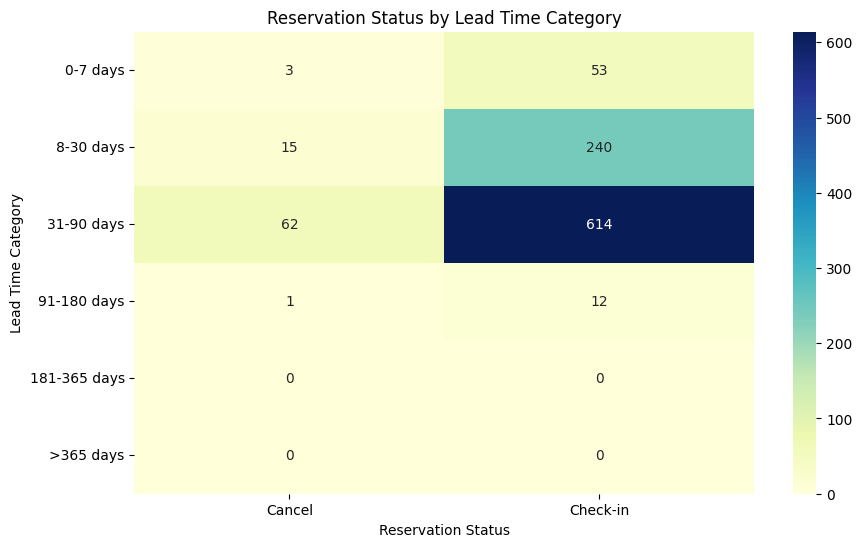

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(lead_time_status_counts, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Reservation Status by Lead Time Category')
plt.xlabel('Reservation Status')
plt.ylabel('Lead Time Category')
plt.show()

### Weekday vs. Weekend Analysis
We will categorize bookings based on the check-in day:
* **Weekday:** Monday, Tuesday, Wednesday, Thursday
* **Weekend:** Friday, Saturday, Sunday

In [42]:
# 1. Create a Day Type helper column
hotel_booking_df['CheckIn_Day'] = hotel_booking_df['Tanggal_CheckIn'].dt.dayofweek
hotel_booking_df['Day_Type'] = hotel_booking_df['CheckIn_Day'].apply(lambda x: 'Weekend' if x >= 4 else 'Weekday')

# 2. Calculate Cancellation Rates
cancel_stats = hotel_booking_df.groupby('Day_Type')['Status_Reservasi'].value_counts(normalize=True).unstack().fillna(0)
cancel_stats['Cancellation_Rate'] = cancel_stats['Cancel'] * 100

# 3. Calculate Spending Profiles
# First, calculate product spending per booking
product_spending_per_booking = hotel_product_df.groupby('Booking_ID')['Total_Price'].sum().reset_index(name='Total_Product_Spending')

# Merge with product spending data
spending_by_day = pd.merge(hotel_booking_df[['Booking_ID', 'Day_Type']], product_spending_per_booking, on='Booking_ID', how='left').fillna(0)
avg_spend = spending_by_day.groupby('Day_Type')['Total_Product_Spending'].mean()

# Display Results
print("--- Cancellation Rate by Day Type (%)")
display(cancel_stats[['Cancellation_Rate']])
print("\n--- Average Ancillary Spend per Booking (IDR)")
display(avg_spend)

--- Cancellation Rate by Day Type (%)


Status_Reservasi,Cancellation_Rate
Day_Type,
Weekday,7.368421
Weekend,9.069767



--- Average Ancillary Spend per Booking (IDR)


,Total_Product_Spending
Day_Type,
Weekday,297587.719298
Weekend,267825.581395


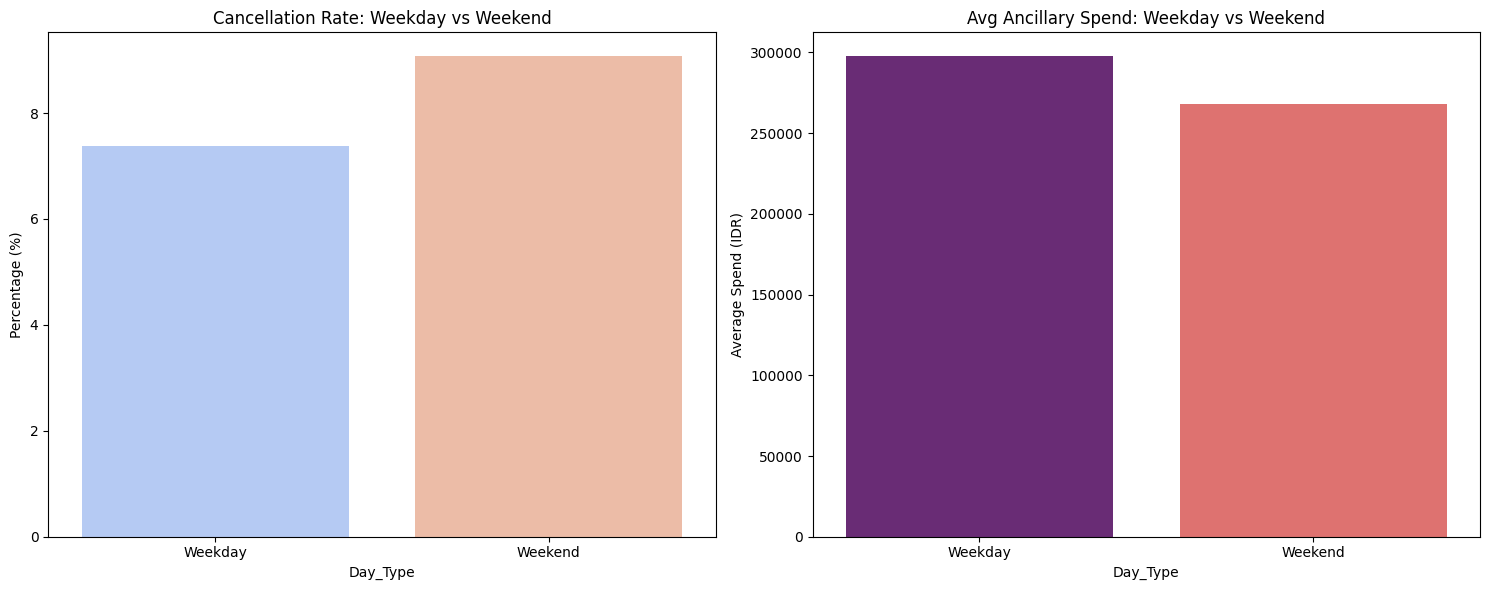

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Cancellation Rate
sns.barplot(x=cancel_stats.index, y=cancel_stats['Cancellation_Rate'], ax=ax[0], palette='coolwarm', hue=cancel_stats.index, legend=False)
ax[0].set_title('Cancellation Rate: Weekday vs Weekend')
ax[0].set_ylabel('Percentage (%)')

# Plot 2: Average Spend
sns.barplot(x=avg_spend.index, y=avg_spend.values, ax=ax[1], palette='magma', hue=avg_spend.index, legend=False)
ax[1].set_title('Avg Ancillary Spend: Weekday vs Weekend')
ax[1].set_ylabel('Average Spend (IDR)')

plt.tight_layout()
plt.show()

# Ancillary Deep-Dive

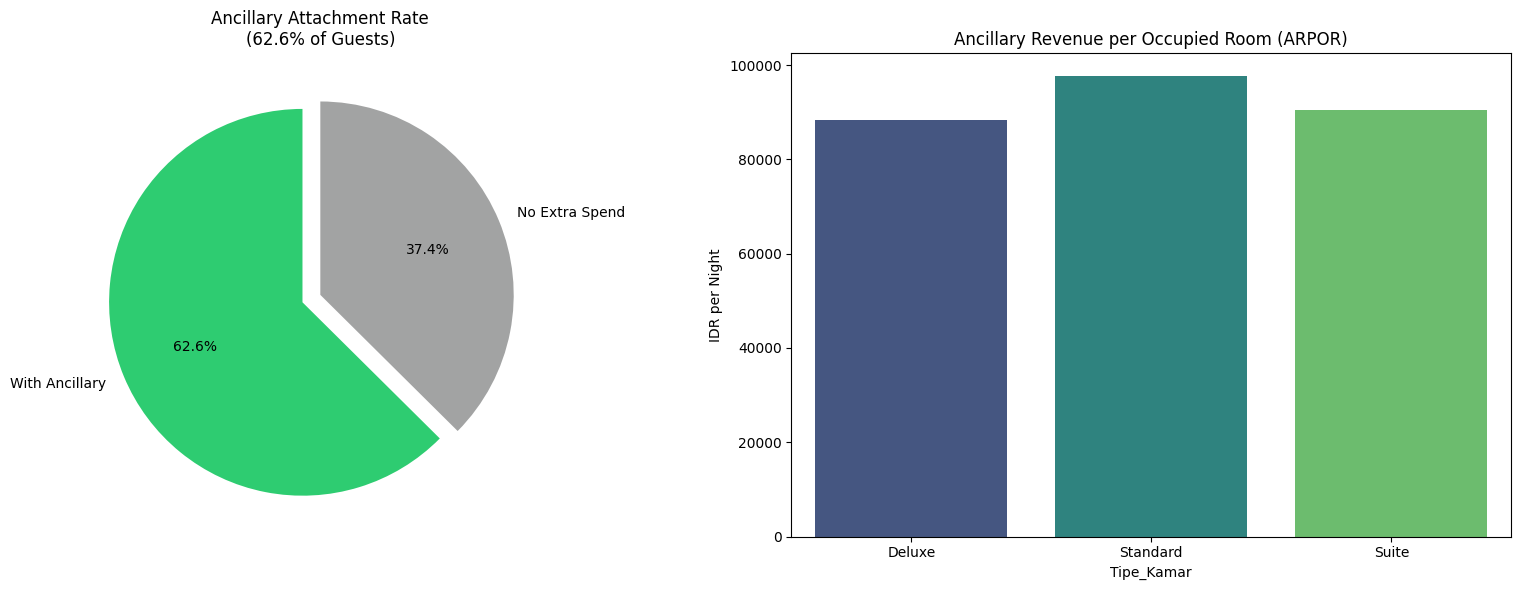

--- Ancillary Monetization Report ---
Attachment Rate: 62.57% (Industry Benchmark for 5-Star: 35%+)
Average Ancillary Spend per Night (Standard): IDR 97,652
Average Ancillary Spend per Night (Suite):    IDR 90,455

--- Strategic Impact ---
By converting 10% more guests to a 'Lazy Morning Bundle' (IDR 350k), 
you could generate an additional IDR 35,000,000 in high-margin revenue.


In [44]:
# 1. Ancillary Attachment Rate
total_realized_bookings = hotel_booking_df[hotel_booking_df['Status_Reservasi'] == 'Check-in']['Booking_ID'].nunique()
bookings_with_ancillary = realized_ancillary_df['Booking_ID'].nunique()

attachment_rate = (bookings_with_ancillary / total_realized_bookings) * 100

# 2. Ancillary Revenue per Occupied Room (ARPOR)
# Use checked_in_only to calculate realized spend per room night
ancillary_spend_per_booking = hotel_product_df.groupby('Booking_ID')['Total_Price'].sum()
checked_in_with_spend = pd.merge(checked_in_only[['Booking_ID', 'Tipe_Kamar', 'Lama_Menginap']],
                                 ancillary_spend_per_booking, on='Booking_ID', how='left').fillna(0)

arpor_by_room = checked_in_with_spend.groupby('Tipe_Kamar').agg(
    Total_Ancillary=('Total_Price', 'sum'),
    Total_Nights=('Lama_Menginap', 'sum')
)
arpor_by_room['ARPOR'] = arpor_by_room['Total_Ancillary'] / arpor_by_room['Total_Nights']

# 3. Quantifying Bundle Impact (Simulation)
# Fix: Define total_bookings before use
total_bookings = len(hotel_booking_df)
lazy_morning_price = 250000 + 100000 # Dinner + Late Checkout
potential_upsell_target = total_bookings * 0.10
projected_revenue_gain = potential_upsell_target * lazy_morning_price

# --- Visualizations ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Attachment Rate Gauge (Textual/Donut)
ax[0].pie([attachment_rate, 100-attachment_rate], labels=['With Ancillary', 'No Extra Spend'],
        autopct='%1.1f%%', colors=['#2ecc71', '#a2a3a3'], startangle=90, explode=(0.1, 0))
ax[0].set_title(f'Ancillary Attachment Rate\n({attachment_rate:.1f}% of Guests)')

# Plot 2: ARPOR by Room Type
sns.barplot(x=arpor_by_room.index, y=arpor_by_room['ARPOR'], ax=ax[1], palette='viridis', hue=arpor_by_room.index, legend=False)
ax[1].set_title('Ancillary Revenue per Occupied Room (ARPOR)')
ax[1].set_ylabel('IDR per Night')

plt.tight_layout()
plt.show()

print(f"--- Ancillary Monetization Report ---")
print(f"Attachment Rate: {attachment_rate:.2f}% (Industry Benchmark for 5-Star: 35%+)")
print(f"Average Ancillary Spend per Night (Standard): IDR {arpor_by_room.loc['Standard', 'ARPOR']:,.0f}")
print(f"Average Ancillary Spend per Night (Suite):    IDR {arpor_by_room.loc['Suite', 'ARPOR']:,.0f}")
print(f"\n--- Strategic Impact ---")
print(f"By converting 10% more guests to a 'Lazy Morning Bundle' (IDR 350k), ")
print(f"you could generate an additional IDR {projected_revenue_gain:,.0f} in high-margin revenue.")

Calculate the total revenue from room bookings and additional products, identify the room type and additional product generating the most revenue, and determine the average extra spend per reservation for each room type using the `hotel_booking_df` and `hotel_product_df` dataframes.

## Calculate average extra spend per reservation by room type

### Subtask:
Calculate the average additional spending per reservation, grouped by room type. This will require merging the booking and product data.


To calculate the average extra spend per reservation by room type, I will first merge the `hotel_booking_df` and `hotel_product_df` on the 'Booking_ID' column to combine booking and product information.



In [45]:
merged_df = pd.merge(hotel_booking_df, hotel_product_df, on='Booking_ID', how='left')

In [46]:
merged_df[merged_df['Status_Reservasi']!='Check-in'].head()

,Booking_ID,Tanggal_Booking,Tanggal_CheckIn,Tanggal_CheckOut,Lama_Menginap,Room_ID,Tipe_Kamar,Harga_per_Malam,Status_Reservasi,Kanal_Distribusi,...,CheckIn_Month,CheckIn_Year,Lead_Time_Category,CheckIn_Day,Day_Type,Product_ID,Product_Name,Quantity,Price_per_Unit,Total_Price
40,B0026,2025-10-29,2025-11-19,2025-11-21,2,SU024,Suite,1000000,Cancel,OTA (Agoda),...,11,2025,8-30 days,2,Weekday,PROD-0175,Breakfast Buffet,1.0,150000.0,150000.0
41,B0026,2025-10-29,2025-11-19,2025-11-21,2,SU024,Suite,1000000,Cancel,OTA (Agoda),...,11,2025,8-30 days,2,Weekday,PROD-0928,Room Service,3.0,180000.0,540000.0
44,B0029,2025-05-05,2025-06-22,2025-06-23,1,ST030,Standard,300000,Cancel,Corporate,...,6,2025,31-90 days,6,Weekend,PROD-0406,Breakfast Buffet,2.0,150000.0,300000.0
68,B0048,2025-01-28,2025-04-08,2025-04-12,4,SU011,Suite,1000000,Cancel,OTA (Agoda),...,4,2025,31-90 days,1,Weekday,PROD-0405,Dinner Buffet,1.0,250000.0,250000.0
69,B0048,2025-01-28,2025-04-08,2025-04-12,4,SU011,Suite,1000000,Cancel,OTA (Agoda),...,4,2025,31-90 days,1,Weekday,PROD-0442,Spa Package,1.0,300000.0,300000.0


In [47]:
extra_spend_per_reservation = merged_df[merged_df['Status_Reservasi']=='Check-in'].groupby(['Tipe_Kamar', 'Booking_ID'])['Total_Price'].sum().reset_index()

In [48]:
revenue_products_leak = merged_df[merged_df['Status_Reservasi']=='Cancel'].groupby(['Tipe_Kamar', 'Booking_ID'])['Total_Price'].sum().reset_index()

To find the average extra spend per reservation for each room type, I will group the `extra_spend_per_reservation` DataFrame by 'Tipe_Kamar' and calculate the mean of 'Total_Price'.



In [49]:
average_extra_spend_per_room_type = extra_spend_per_reservation.groupby('Tipe_Kamar')['Total_Price'].mean()
print("Average extra spend per reservation by room type:")
print(average_extra_spend_per_room_type)

Average extra spend per reservation by room type:
Tipe_Kamar
Deluxe      272110.389610
Standard    287054.380665
Suite       280732.142857
Name: Total_Price, dtype: float64


In [50]:
total_extra_spend_per_room_type = extra_spend_per_reservation.groupby('Tipe_Kamar')['Total_Price'].sum()
print("Total extra spend per reservation by room type:")
print(total_extra_spend_per_room_type)

Total extra spend per reservation by room type:
Tipe_Kamar
Deluxe      83810000.0
Standard    95015000.0
Suite       78605000.0
Name: Total_Price, dtype: float64


In [51]:
total_leak_per_room_type = revenue_products_leak.groupby('Tipe_Kamar')['Total_Price'].sum()
print("Average extra spend per reservation by room type:")
print(total_leak_per_room_type)

Average extra spend per reservation by room type:
Tipe_Kamar
Deluxe      10945000.0
Standard     6585000.0
Suite        9830000.0
Name: Total_Price, dtype: float64


In [52]:
mean_leak_per_room_type = revenue_products_leak.groupby('Tipe_Kamar')['Total_Price'].mean()
print("Average extra spend per reservation by room type:")
print(mean_leak_per_room_type)

Average extra spend per reservation by room type:
Tipe_Kamar
Deluxe      312714.285714
Standard    387352.941176
Suite       338965.517241
Name: Total_Price, dtype: float64


In [53]:
merged_product_channel_df = pd.merge(hotel_booking_df, hotel_product_df, on='Booking_ID', how='right')
cancelled_product_purchases = merged_product_channel_df[merged_product_channel_df['Status_Reservasi'] == 'Cancel']
cancelled_product_quantity = cancelled_product_purchases.groupby('Product_Name')['Quantity'].sum().reset_index()
cancelled_product_quantity = cancelled_product_quantity.sort_values(by='Quantity', ascending=False)

print("Total quantity of each product purchased for cancelled reservations:")
print(cancelled_product_quantity)

Total quantity of each product purchased for cancelled reservations:
       Product_Name  Quantity
1  Breakfast Buffet        21
0  Airport Transfer        17
7      Room Service        15
9      Tour Package        13
8       Spa Package        11
3     Late Checkout        10
5   Massage Service        10
2     Dinner Buffet         9
4   Laundry Service         8
6   Mini Bar Refill         8


In [54]:
cancelled_product_revenue = cancelled_product_purchases.groupby('Product_Name')['Total_Price'].sum().reset_index()
cancelled_product_revenue = cancelled_product_revenue.sort_values(by='Total_Price', ascending=False)

print("Total revenue per product for cancelled reservations:")
print(cancelled_product_revenue)

Total revenue per product for cancelled reservations:
       Product_Name  Total_Price
9      Tour Package      6500000
5   Massage Service      3500000
0  Airport Transfer      3400000
8       Spa Package      3300000
1  Breakfast Buffet      3150000
7      Room Service      2700000
2     Dinner Buffet      2250000
3     Late Checkout      1000000
6   Mini Bar Refill       960000
4   Laundry Service       600000


In [55]:
product_frequency = cancelled_product_purchases.groupby('Product_Name').size().reset_index(name='Purchase_Frequency')
product_sum_price = cancelled_product_purchases.groupby('Product_Name')['Total_Price'].sum().reset_index(name='Sum_Price')
product_avg_unit_price = cancelled_product_purchases.groupby('Product_Name')['Price_per_Unit'].mean().reset_index(name='Average_Price_per_Unit')

# Merge these three dataframes
product_data = pd.merge(product_frequency, product_sum_price, on='Product_Name', how='inner')
product_data = pd.merge(product_data, product_avg_unit_price, on='Product_Name', how='inner')

display(product_data[['Product_Name', 'Purchase_Frequency', 'Sum_Price', 'Average_Price_per_Unit']]
        .sort_values(by='Sum_Price', ascending=False)
        .rename(columns={'Purchase_Frequency': 'Frequency', 'Average_Price_per_Unit': 'Average_Price'}))

,Product_Name,Frequency,Sum_Price,Average_Price
9,Tour Package,13,6500000,500000.0
5,Massage Service,10,3500000,350000.0
0,Airport Transfer,12,3400000,200000.0
8,Spa Package,11,3300000,300000.0
1,Breakfast Buffet,13,3150000,150000.0
7,Room Service,8,2700000,180000.0
2,Dinner Buffet,6,2250000,250000.0
3,Late Checkout,10,1000000,100000.0
6,Mini Bar Refill,8,960000,120000.0
4,Laundry Service,5,600000,75000.0


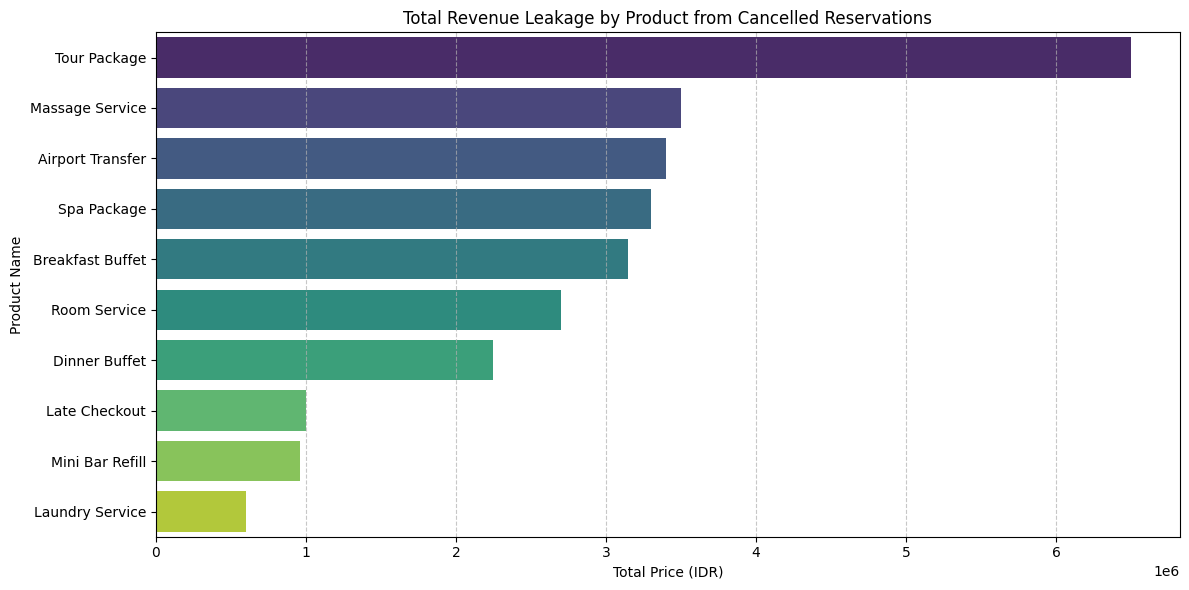

In [56]:
# Revenue Leakage by Product from Cancelled Reservations

plt.figure(figsize=(12, 6))
sns.barplot(x='Total_Price', y='Product_Name', data=cancelled_product_revenue, palette='viridis', hue='Product_Name', legend=False)
plt.title('Total Revenue Leakage by Product from Cancelled Reservations')
plt.xlabel('Total Price (IDR)')
plt.ylabel('Product Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

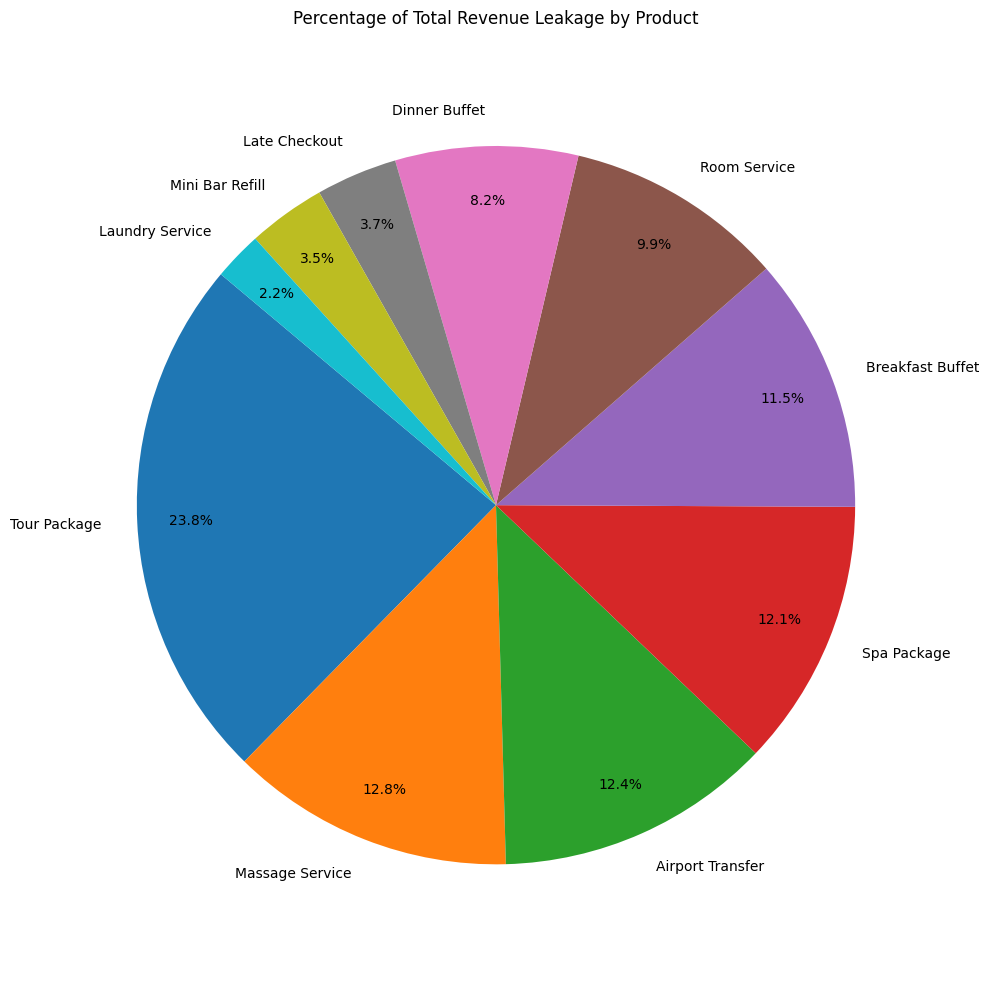

,Product_Name,Total_Price,Percentage_Contribution
9,Tour Package,6500000,23.757310
5,Massage Service,3500000,12.792398
0,Airport Transfer,3400000,12.426901
8,Spa Package,3300000,12.061404
1,Breakfast Buffet,3150000,11.513158
7,Room Service,2700000,9.868421
2,Dinner Buffet,2250000,8.223684
3,Late Checkout,1000000,3.654971
6,Mini Bar Refill,960000,3.508772
4,Laundry Service,600000,2.192982


In [57]:
# Calculate the total revenue leakage
total_leakage = cancelled_product_revenue['Total_Price'].sum()

# Calculate the percentage contribution of each product
cancelled_product_revenue['Percentage_Contribution'] = (cancelled_product_revenue['Total_Price'] / total_leakage) * 100

# Sort by percentage for better visualization
cancelled_product_revenue = cancelled_product_revenue.sort_values(by='Percentage_Contribution', ascending=False)

# Create the pie chart
plt.figure(figsize=(10, 10))
plt.pie(cancelled_product_revenue['Percentage_Contribution'],
        labels=cancelled_product_revenue['Product_Name'],
        autopct='%1.1f%%',
        startangle=140,
        pctdistance=0.85) # Adjust pctdistance to place percentages inside slices

plt.title('Percentage of Total Revenue Leakage by Product')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

display(cancelled_product_revenue[['Product_Name', 'Total_Price', 'Percentage_Contribution']])

### Compare Revenue Leakage Percentage (Cancelled) vs. Revenue Contribution (Checked-in) by Product

In [58]:
# Filter for checked-in product purchases
checked_in_product_purchases_df = merged_product_channel_df[merged_product_channel_df['Status_Reservasi'] == 'Check-in']

# Group by Product_Name and sum Total_Price for checked-in reservations
checked_in_product_revenue_df = checked_in_product_purchases_df.groupby('Product_Name')['Total_Price'].sum().reset_index()

# Calculate total revenue from checked-in products
total_checked_in_revenue = checked_in_product_revenue_df['Total_Price'].sum()

# Calculate percentage contribution for each checked-in product
checked_in_product_revenue_df['Percentage_Contribution'] = (checked_in_product_revenue_df['Total_Price'] / total_checked_in_revenue) * 100

# Add a 'Status' column for identification during comparison
checked_in_product_revenue_df['Status'] = 'Checked-in'

# Prepare the cancelled_product_revenue with a 'Status' column (already calculated in previous steps)
cancelled_product_revenue['Status'] = 'Cancelled'

# Combine both dataframes for comparison
comparison_df = pd.concat([checked_in_product_revenue_df, cancelled_product_revenue], ignore_index=True)

# Sort for better visualization
comparison_df = comparison_df.sort_values(by=['Product_Name', 'Status'])

display(comparison_df.head())

,Product_Name,Total_Price,Percentage_Contribution,Status
12,Airport Transfer,3400000,12.426901,Cancelled
0,Airport Transfer,32000000,12.430564,Checked-in
14,Breakfast Buffet,3150000,11.513158,Cancelled
1,Breakfast Buffet,22950000,8.915045,Checked-in
16,Dinner Buffet,2250000,8.223684,Cancelled


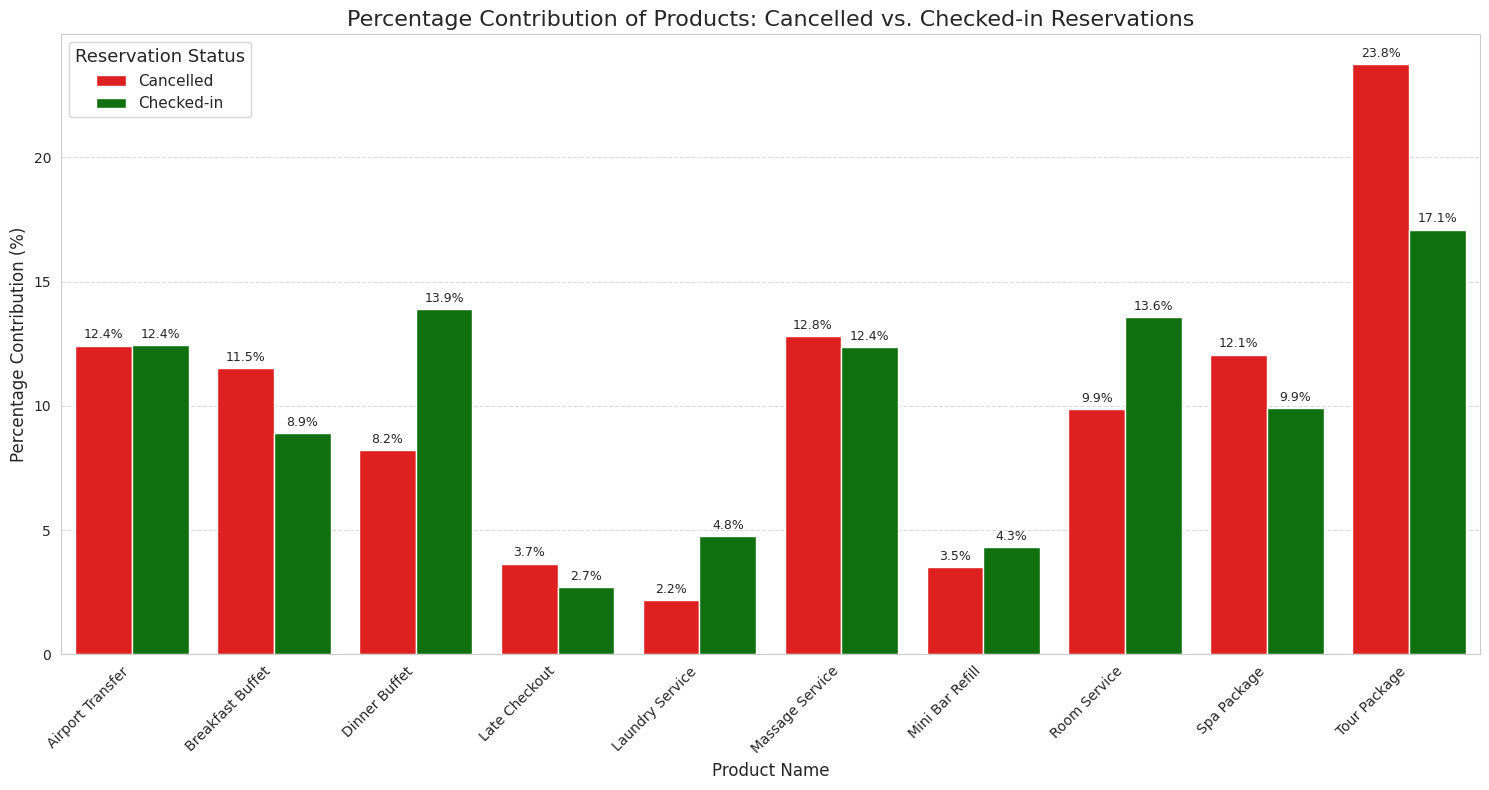

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid") # Set a nice style
ax = sns.barplot(x='Product_Name', y='Percentage_Contribution', hue='Status', data=comparison_df, palette={'Cancelled': 'red', 'Checked-in': 'green'})
plt.title('Percentage Contribution of Products: Cancelled vs. Checked-in Reservations', fontsize=16)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Percentage Contribution (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Reservation Status', title_fontsize='13', fontsize='11')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=3)

plt.tight_layout()
plt.show()

In [60]:
# Pivot the comparison_df to get status percentages as columns
diff_df = comparison_df.pivot(index='Product_Name', columns='Status', values='Percentage_Contribution').reset_index()

# Calculate the difference (Cancelled % minus Checked-in %)
diff_df['Difference_Percentage'] = diff_df['Cancelled'] - diff_df['Checked-in']

# Sort by the magnitude of the difference
diff_df = diff_df.sort_values(by='Difference_Percentage', ascending=False).reset_index()

print("Difference in Percentage Contribution (Cancelled vs Checked-in):")
display(diff_df.round(2))

Difference in Percentage Contribution (Cancelled vs Checked-in):


Status,index,Product_Name,Cancelled,Checked-in,Difference_Percentage
0,9,Tour Package,23.76,17.09,6.67
1,1,Breakfast Buffet,11.51,8.92,2.60
2,8,Spa Package,12.06,9.91,2.16
3,3,Late Checkout,3.65,2.72,0.94
4,5,Massage Service,12.79,12.37,0.42
5,0,Airport Transfer,12.43,12.43,-0.00
6,6,Mini Bar Refill,3.51,4.34,-0.83
7,4,Laundry Service,2.19,4.78,-2.59
8,7,Room Service,9.87,13.56,-3.70
9,2,Dinner Buffet,8.22,13.89,-5.66


## Identify product purchase patterns by distribution channel

### Subtask:
Analyze if certain additional products are exclusively or predominantly bought by guests from specific distribution channels.


In [61]:
merged_product_channel_df.head()

,Booking_ID,Tanggal_Booking,Tanggal_CheckIn,Tanggal_CheckOut,Lama_Menginap,Room_ID,Tipe_Kamar,Harga_per_Malam,Status_Reservasi,Kanal_Distribusi,...,CheckIn_Month,CheckIn_Year,Lead_Time_Category,CheckIn_Day,Day_Type,Product_ID,Product_Name,Quantity,Price_per_Unit,Total_Price
0,B0822,2025-07-25,2025-09-22,2025-09-23,1,DE071,Deluxe,500000,Check-in,OTA (Agoda),...,9,2025,31-90 days,0,Weekday,PROD-0001,Late Checkout,1,100000,100000
1,B0308,2025-04-05,2025-06-24,2025-06-27,3,ST009,Standard,300000,Check-in,OTA (Booking.com),...,6,2025,31-90 days,1,Weekday,PROD-0002,Late Checkout,1,100000,100000
2,B0669,2025-05-19,2025-07-12,2025-07-15,3,ST064,Standard,300000,Check-in,OTA (Booking.com),...,7,2025,31-90 days,5,Weekend,PROD-0003,Massage Service,1,350000,350000
3,B0214,2025-04-30,2025-05-17,2025-05-19,2,DE065,Deluxe,500000,Check-in,OTA (Booking.com),...,5,2025,8-30 days,5,Weekend,PROD-0004,Laundry Service,3,75000,225000
4,B0282,2025-09-01,2025-09-26,2025-09-28,2,DE094,Deluxe,500000,Check-in,OTA (Agoda),...,9,2025,8-30 days,4,Weekend,PROD-0005,Mini Bar Refill,1,120000,120000


**Reasoning**:
To understand product purchase patterns, I will group the `merged_product_channel_df` by 'Kanal_Distribusi' and 'Product_Name' and then sum the 'Total_Price' to get the total revenue generated by each product within each distribution channel.



In [62]:
product_channel_revenue = merged_product_channel_df.groupby(['Kanal_Distribusi', 'Product_Name'])['Total_Price'].sum().reset_index()
print("Total revenue for each product by distribution channel:")
print(product_channel_revenue.head(10))


Total revenue for each product by distribution channel:
  Kanal_Distribusi      Product_Name  Total_Price
0        Corporate  Airport Transfer      1200000
1        Corporate  Breakfast Buffet      3000000
2        Corporate     Dinner Buffet      4000000
3        Corporate     Late Checkout       800000
4        Corporate   Laundry Service       525000
5        Corporate   Massage Service      3150000
6        Corporate   Mini Bar Refill       600000
7        Corporate      Room Service      4320000
8        Corporate       Spa Package      1500000
9        Corporate      Tour Package      3500000


**Reasoning**:
To analyze purchase patterns and identify products predominantly bought through specific channels, I will first determine the number of unique distribution channels each product is sold through. This helps in identifying products that might be exclusive to certain channels.



In [63]:
product_channel_counts = product_channel_revenue.groupby('Product_Name')['Kanal_Distribusi'].nunique().reset_index()
product_channel_counts.rename(columns={'Kanal_Distribusi': 'Num_Channels_Sold'}, inplace=True)
exclusive_products = product_channel_counts[product_channel_counts['Num_Channels_Sold'] == 1]
print("Products sold through only one distribution channel:")
print(exclusive_products)

Products sold through only one distribution channel:
Empty DataFrame
Columns: [Product_Name, Num_Channels_Sold]
Index: []


**Reasoning**:
Since no products are exclusively sold through a single channel, I will now identify products that are predominantly bought through specific channels. To do this, I will calculate the total revenue for each product, then the percentage of each product's revenue contributed by each channel. Finally, I will identify the channel that contributes the highest proportion of revenue for each product.



In [64]:
product_total_revenue = merged_product_channel_df.groupby('Product_Name')['Total_Price'].sum().reset_index()
product_total_revenue.rename(columns={'Total_Price': 'Product_Overall_Revenue'}, inplace=True)

product_channel_proportion = pd.merge(product_channel_revenue, product_total_revenue, on='Product_Name', how='left')
product_channel_proportion['Revenue_Proportion'] = product_channel_proportion['Total_Price'] / product_channel_proportion['Product_Overall_Revenue']

predominant_channels = product_channel_proportion.loc[product_channel_proportion.groupby('Product_Name')['Revenue_Proportion'].idxmax()]

print("Products and their predominant distribution channels:")
print(predominant_channels[['Product_Name', 'Kanal_Distribusi', 'Revenue_Proportion']].round(2))

Products and their predominant distribution channels:
        Product_Name   Kanal_Distribusi  Revenue_Proportion
30  Airport Transfer  OTA (Booking.com)                0.44
31  Breakfast Buffet  OTA (Booking.com)                0.34
32     Dinner Buffet  OTA (Booking.com)                0.39
33     Late Checkout  OTA (Booking.com)                0.36
34   Laundry Service  OTA (Booking.com)                0.51
35   Massage Service  OTA (Booking.com)                0.43
36   Mini Bar Refill  OTA (Booking.com)                0.39
37      Room Service  OTA (Booking.com)                0.40
38       Spa Package  OTA (Booking.com)                0.41
39      Tour Package  OTA (Booking.com)                0.36


## Identify high-frequency, low-price additional products

### Subtask:
Find additional products that are frequently purchased but have a low price per unit.


In [65]:
product_frequency = hotel_product_df.groupby('Product_Name').size().reset_index(name='Purchase_Frequency')
print("Product Purchase Frequency:")
print(product_frequency.head())

Product Purchase Frequency:
       Product_Name  Purchase_Frequency
0  Airport Transfer                 120
1  Breakfast Buffet                 109
2     Dinner Buffet                 100
3     Late Checkout                  80
4   Laundry Service                  85


**Reasoning**:
To continue identifying high-frequency, low-price products, I will now calculate the average 'Price_per_Unit' for each unique 'Product_Name' from the `hotel_product_df` and store it in a new DataFrame called `product_avg_price`.



In [66]:
product_avg_price = hotel_product_df.groupby('Product_Name')['Price_per_Unit'].mean().reset_index(name='Average_Price_per_Unit')
print("Product Average Price per Unit:")
print(product_avg_price.head())

Product Average Price per Unit:
       Product_Name  Average_Price_per_Unit
0  Airport Transfer                200000.0
1  Breakfast Buffet                150000.0
2     Dinner Buffet                250000.0
3     Late Checkout                100000.0
4   Laundry Service                 75000.0


**Reasoning**:
To identify high-frequency, low-price additional products, I will merge the `product_frequency` and `product_avg_price` DataFrames based on the 'Product_Name' column.



In [67]:
product_data = pd.merge(product_frequency, product_avg_price, on='Product_Name', how='inner')
print("Merged product frequency and average price data:")
print(product_data.head())

Merged product frequency and average price data:
       Product_Name  Purchase_Frequency  Average_Price_per_Unit
0  Airport Transfer                 120                200000.0
1  Breakfast Buffet                 109                150000.0
2     Dinner Buffet                 100                250000.0
3     Late Checkout                  80                100000.0
4   Laundry Service                  85                 75000.0


**Reasoning**:
To easily identify high-frequency, low-price products, I will sort the `product_data` DataFrame by 'Purchase_Frequency' in descending order and by 'Average_Price_per_Unit' in ascending order, then print the result.



In [68]:
sorted_products = product_data.sort_values(by=['Purchase_Frequency', 'Average_Price_per_Unit'], ascending=[False, True])
print("High-frequency, low-price additional products (sorted):")
print(sorted_products)

High-frequency, low-price additional products (sorted):
       Product_Name  Purchase_Frequency  Average_Price_per_Unit
0  Airport Transfer                 120                200000.0
1  Breakfast Buffet                 109                150000.0
7      Room Service                 107                180000.0
6   Mini Bar Refill                 101                120000.0
5   Massage Service                 101                350000.0
9      Tour Package                 101                500000.0
2     Dinner Buffet                 100                250000.0
8       Spa Package                  96                300000.0
4   Laundry Service                  85                 75000.0
3     Late Checkout                  80                100000.0


## Identify bundling opportunities for products and room types

### Subtask:
Analyze purchase patterns to suggest additional products that could be bundled with specific room types to increase transaction value.


In [69]:
merged_room_product_df = pd.merge(hotel_booking_df, hotel_product_df, on='Booking_ID', how='right')
print("Merged DataFrame (hotel_booking_df and hotel_product_df) for room type and product analysis. First 5 rows:")

Merged DataFrame (hotel_booking_df and hotel_product_df) for room type and product analysis. First 5 rows:


In [70]:
merged_room_product_df.head()

,Booking_ID,Tanggal_Booking,Tanggal_CheckIn,Tanggal_CheckOut,Lama_Menginap,Room_ID,Tipe_Kamar,Harga_per_Malam,Status_Reservasi,Kanal_Distribusi,...,CheckIn_Month,CheckIn_Year,Lead_Time_Category,CheckIn_Day,Day_Type,Product_ID,Product_Name,Quantity,Price_per_Unit,Total_Price
0,B0822,2025-07-25,2025-09-22,2025-09-23,1,DE071,Deluxe,500000,Check-in,OTA (Agoda),...,9,2025,31-90 days,0,Weekday,PROD-0001,Late Checkout,1,100000,100000
1,B0308,2025-04-05,2025-06-24,2025-06-27,3,ST009,Standard,300000,Check-in,OTA (Booking.com),...,6,2025,31-90 days,1,Weekday,PROD-0002,Late Checkout,1,100000,100000
2,B0669,2025-05-19,2025-07-12,2025-07-15,3,ST064,Standard,300000,Check-in,OTA (Booking.com),...,7,2025,31-90 days,5,Weekend,PROD-0003,Massage Service,1,350000,350000
3,B0214,2025-04-30,2025-05-17,2025-05-19,2,DE065,Deluxe,500000,Check-in,OTA (Booking.com),...,5,2025,8-30 days,5,Weekend,PROD-0004,Laundry Service,3,75000,225000
4,B0282,2025-09-01,2025-09-26,2025-09-28,2,DE094,Deluxe,500000,Check-in,OTA (Agoda),...,9,2025,8-30 days,4,Weekend,PROD-0005,Mini Bar Refill,1,120000,120000


**Reasoning**:
Now that the dataframes are merged, I will group the `merged_room_product_df` by 'Tipe_Kamar' and 'Product_Name' and count the number of occurrences of each product for each room type. This will show how frequently each additional product is purchased with each room type.



In [71]:
product_purchases_by_room_type = merged_room_product_df.groupby(['Tipe_Kamar', 'Product_Name']).size().reset_index(name='Purchase_Count')
print("Product purchase counts by room type (first 10 rows):")
print(product_purchases_by_room_type.head(10))

Product purchase counts by room type (first 10 rows):
  Tipe_Kamar      Product_Name  Purchase_Count
0     Deluxe  Airport Transfer              51
1     Deluxe  Breakfast Buffet              37
2     Deluxe     Dinner Buffet              39
3     Deluxe     Late Checkout              24
4     Deluxe   Laundry Service              32
5     Deluxe   Massage Service              27
6     Deluxe   Mini Bar Refill              34
7     Deluxe      Room Service              30
8     Deluxe       Spa Package              35
9     Deluxe      Tour Package              29


**Reasoning**:
To better visualize the association between room types and product purchases, I will pivot the `product_purchases_by_room_type` DataFrame. This will set 'Tipe_Kamar' as the index, 'Product_Name' as columns, and 'Purchase_Count' as values, filling any non-existent combinations with 0.



In [72]:
room_product_pivot = product_purchases_by_room_type.pivot_table(index='Tipe_Kamar', columns='Product_Name', values='Purchase_Count').fillna(0)
print("Pivoted table showing product purchases by room type:")

Pivoted table showing product purchases by room type:


In [73]:
room_product_pivot

Product_Name,Airport Transfer,Breakfast Buffet,Dinner Buffet,Late Checkout,Laundry Service,Massage Service,Mini Bar Refill,Room Service,Spa Package,Tour Package
Tipe_Kamar,,,,,,,,,,
Deluxe,51.0,37.0,39.0,24.0,32.0,27.0,34.0,30.0,35.0,29.0
Standard,43.0,36.0,33.0,32.0,26.0,30.0,31.0,45.0,28.0,40.0
Suite,26.0,36.0,28.0,24.0,27.0,44.0,36.0,32.0,33.0,32.0


**Reasoning**:
To identify products predominantly purchased with specific room types, I will calculate the proportion of each product's purchases that come from each room type. This involves dividing each value in the `room_product_pivot` by the sum of its respective column (product total purchases).



In [74]:
product_proportions_by_room_type = room_product_pivot.apply(lambda x: x / x.sum(), axis=0)
print("Proportion of each product's purchases by room type (showing strong associations):")

Proportion of each product's purchases by room type (showing strong associations):


In [75]:
product_proportions_by_room_type.round(2)

Product_Name,Airport Transfer,Breakfast Buffet,Dinner Buffet,Late Checkout,Laundry Service,Massage Service,Mini Bar Refill,Room Service,Spa Package,Tour Package
Tipe_Kamar,,,,,,,,,,
Deluxe,0.42,0.34,0.39,0.3,0.38,0.27,0.34,0.28,0.36,0.29
Standard,0.36,0.33,0.33,0.4,0.31,0.30,0.31,0.42,0.29,0.40
Suite,0.22,0.33,0.28,0.3,0.32,0.44,0.36,0.30,0.34,0.32


**Reasoning**:
To identify specific bundling opportunities, I will now analyze the `product_proportions_by_room_type` DataFrame. For each room type, I will identify the top 3 products with the highest purchase proportions, which indicates a strong association and potential for bundling.



In [76]:
print("Top 3 products for each room type for bundling opportunities:")
for room_type in product_proportions_by_room_type.index:
    top_products = product_proportions_by_room_type.loc[room_type].nlargest(3)
    print(f"\nRoom Type: {room_type}")
    for product_name, proportion in top_products.items():
        print(f"  - {product_name}: {proportion:.2f}")

Top 3 products for each room type for bundling opportunities:

Room Type: Deluxe
  - Airport Transfer: 0.42
  - Dinner Buffet: 0.39
  - Laundry Service: 0.38

Room Type: Standard
  - Room Service: 0.42
  - Late Checkout: 0.40
  - Tour Package: 0.40

Room Type: Suite
  - Massage Service: 0.44
  - Mini Bar Refill: 0.36
  - Spa Package: 0.34


## Market Basket Analysis: Product Association Mapping

We will now use a pivot table to see which products are purchased together in the same booking. This will help validate if our suggested bundles (like 'Suite Wellness') are backed by actual guest behavior.

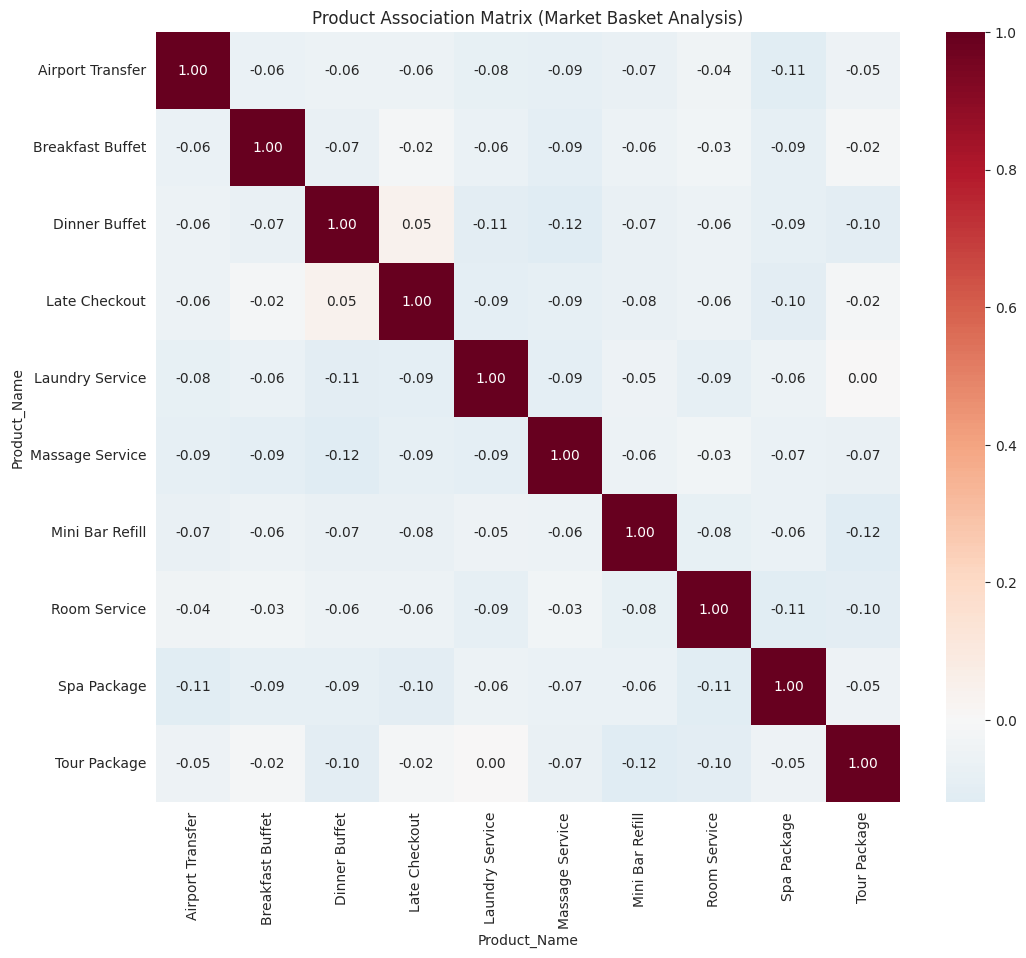

In [77]:
# 1. Create a binary matrix: 1 if product was bought in a booking, 0 otherwise
basket = hotel_product_df.groupby(['Booking_ID', 'Product_Name'])['Quantity'].sum().unstack().reset_index().fillna(0).set_index('Booking_ID')
basket = basket.map(lambda x: 1 if x > 0 else 0)

# 2. Calculate the correlation between products
product_correlation = basket.corr()

# 3. Visualize the associations using a Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(product_correlation, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Product Association Matrix (Market Basket Analysis)')
plt.show()

In [78]:
import numpy as np

# Identify the strongest associations (excluding self-correlation)
sol = (product_correlation.where(np.triu(np.ones(product_correlation.shape), k=1).astype(bool))
                  .stack()
                  .sort_values(ascending=False))

print("Top 5 Strongest Product Associations:")
display(sol.head(5))

Top 5 Strongest Product Associations:


Product_Name      Product_Name 
Dinner Buffet     Late Checkout    0.046601
Laundry Service   Tour Package     0.003457
Late Checkout     Tour Package    -0.019636
Breakfast Buffet  Tour Package    -0.019800
                  Late Checkout   -0.020029
dtype: float64

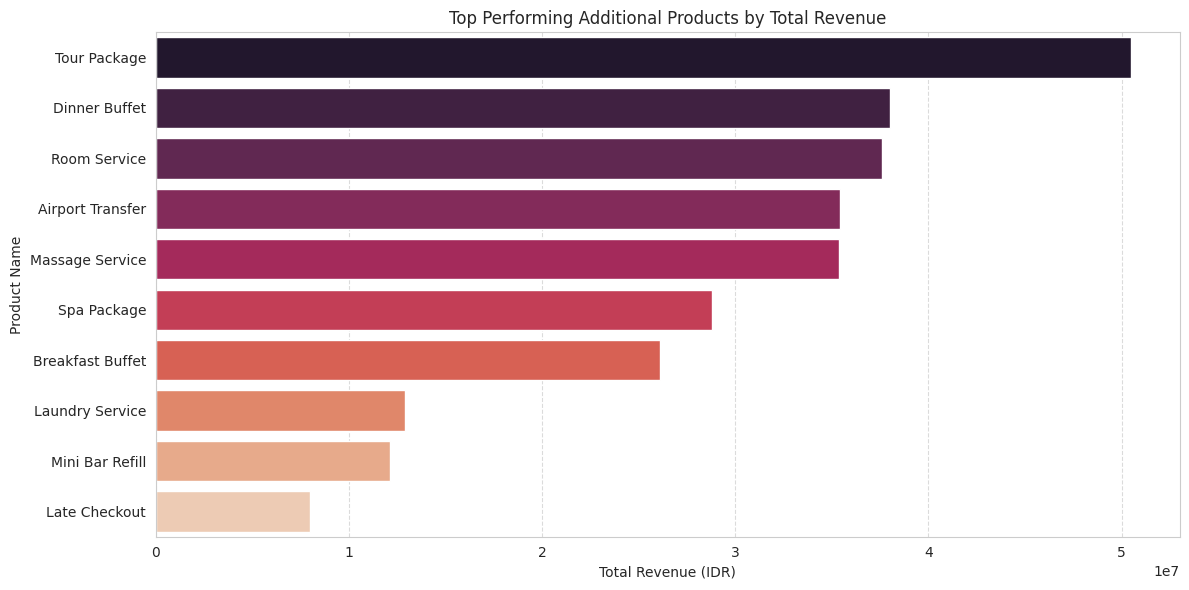

,Product_Name,Total_Price
9,Tour Package,50500000
2,Dinner Buffet,38000000
7,Room Service,37620000
0,Airport Transfer,35400000
5,Massage Service,35350000
8,Spa Package,28800000
1,Breakfast Buffet,26100000
4,Laundry Service,12900000
6,Mini Bar Refill,12120000
3,Late Checkout,8000000


In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total revenue per product
product_revenue = hotel_product_df.groupby('Product_Name')['Total_Price'].sum().reset_index()
product_revenue = product_revenue.sort_values(by='Total_Price', ascending=False)

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=product_revenue, x='Total_Price', y='Product_Name', palette='rocket', hue='Product_Name', legend=False)
plt.title('Top Performing Additional Products by Total Revenue')
plt.xlabel('Total Revenue (IDR)')
plt.ylabel('Product Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

display(product_revenue)

### **Executive Revenue Report: Performance & Strategic Outlook (2025)**

**To:** General Manager  
**From:** Revenue Manager  
**Date:** October 2025  

---

#### **1. Revenue Overview & Health Check**
*   **Total Realized Revenue:** IDR 1,892,830,000
    *   **Room Revenue:** IDR 1,635,400,000 (86.4%)
    *   **Ancillary Revenue:** IDR 257,430,000 (13.6%)
*   **Occupancy & Yield:** While maintaining a healthy **ADR of IDR 585,955**, our **Occupancy Rate stands at 8.31%**. This results in a **RevPAR of IDR 48,701**, indicating significant inventory perishability and room for volume growth.

#### **2. Room Type Performance**
*   **Top Revenue Generator:** The **Suite** category is our primary driver, contributing **IDR 869,000,000** to room revenue.
*   **Ancillary Spending Profile:**
    *   **Standard Rooms:** Highest Average Extra Spend per Night (**IDR 97,652**).
    *   **Suites:** Highest Total Extra Spend per Booking (**IDR 280,732**), predominantly driven by *Massage and Spa Services*.
    *   **Deluxe Rooms:** Average Extra Spend per Booking of **IDR 272,110**.

#### **3. Booking Patterns & Distribution**
*   **Average Lead Time:** Guests book on average **46–50 days** in advance during peak periods, though this drops significantly to **9 days** in December.
*   **Channel Behavior:**
    *   **OTA (Booking.com)** is our dominant channel, contributing the highest ADR and the majority of ancillary sales (approx. 40-50% across all product categories).
    *   **Direct Booking** guests show the highest 'Net Revenue' quality due to zero commission costs.
*   **Stay Duration vs. Spend:** There is a moderate positive correlation between Length of Stay (LOS) and ancillary spending; however, **Standard guests** often compensate for shorter stays with high-frequency purchases like *Room Service* and *Late Checkouts*.

#### **4. Revenue Leakage (Cancellations)**
*   **Realized Leakage:** We lost **IDR 178,260,000** this year due to cancellations.
*   **High-Risk Segment:** Bookings made **31-60 days** in advance through **OTA (Agoda)** have the highest cancellation probability (10.48%).

---

#### **Strategic Recommendations**

1.  **Volume Stimulation:** Given the low occupancy (8.31%), implement a **'Last-Minute Flash Sale'** for the 0-7 day window to capture short-lead demand, which currently only accounts for 5.6% of our business.
2.  **Ancillary Bundling:** Launch the **'Suite Wellness Package'** (including Massage/Spa) and the **'Standard Business Bundle'** (including Room Service/Late Checkout). This targets the specific preferences identified for each room type.
3.  **Cancellation Mitigation:** Introduce **Non-Refundable Rates** for the 31-60 day booking window on high-risk OTA channels to protect the IDR 132 Million currently 'at risk'.
4.  **Channel Shift:** Incentivize **Direct Bookings** through a loyalty 'Ancillary Credit' (e.g., IDR 50k spa voucher). This saves the 18% commission paid to OTAs while increasing the Ancillary Attachment Rate.